In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
sns.set_style("whitegrid")

In [9]:
# Update the path if needed
df = pd.read_csv("winequality-white.csv")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()

Missing values: 0


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [10]:
print("\nDescriptive stats:")
df.describe().round(3)


Descriptive stats:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000,4898.000,4898.000,4898.000,4898.000,4898.000,4898.000,4898.000,4898.000,4898.000,4898.000,4898.000
mean,6.855,0.278,0.334,6.391,0.046,35.308,138.361,0.994,3.188,0.490,10.514,5.878
std,0.844,0.101,0.121,5.072,0.022,17.007,42.498,0.003,0.151,0.114,1.231,0.886
min,3.800,0.080,0.000,0.600,0.009,2.000,9.000,0.987,2.720,0.220,8.000,3.000
25%,6.300,0.210,0.270,1.700,0.036,23.000,108.000,0.992,3.090,0.410,9.500,5.000
50%,6.800,0.260,0.320,5.200,0.043,34.000,134.000,0.994,3.180,0.470,10.400,6.000
75%,7.300,0.320,0.390,9.900,0.050,46.000,167.000,0.996,3.280,0.550,11.400,6.000
max,14.200,1.100,1.660,65.800,0.346,289.000,440.000,1.039,3.820,1.080,14.200,9.000


In [11]:
feature_cols = [
    "fixed acidity", "volatile acidity", "citric acid", "residual sugar",
    "chlorides", "free sulfur dioxide", "total sulfur dioxide", "density",
    "pH", "sulphates", "alcohol",
]
target_col = "quality"

# list = list1 + list2 = [ad, cac, adf] + [quality]
# list = list 1 + string -> wrong
corr = df[feature_cols + [target_col]].corr()

target_corr = corr[target_col].drop(target_col).sort_values(key=abs, ascending=False)
print(target_corr.round(3).to_string())

alcohol                 0.436
density                -0.307
chlorides              -0.210
volatile acidity       -0.195
total sulfur dioxide   -0.175
fixed acidity          -0.114
pH                      0.099
residual sugar         -0.098
sulphates               0.054
citric acid            -0.009
free sulfur dioxide     0.008


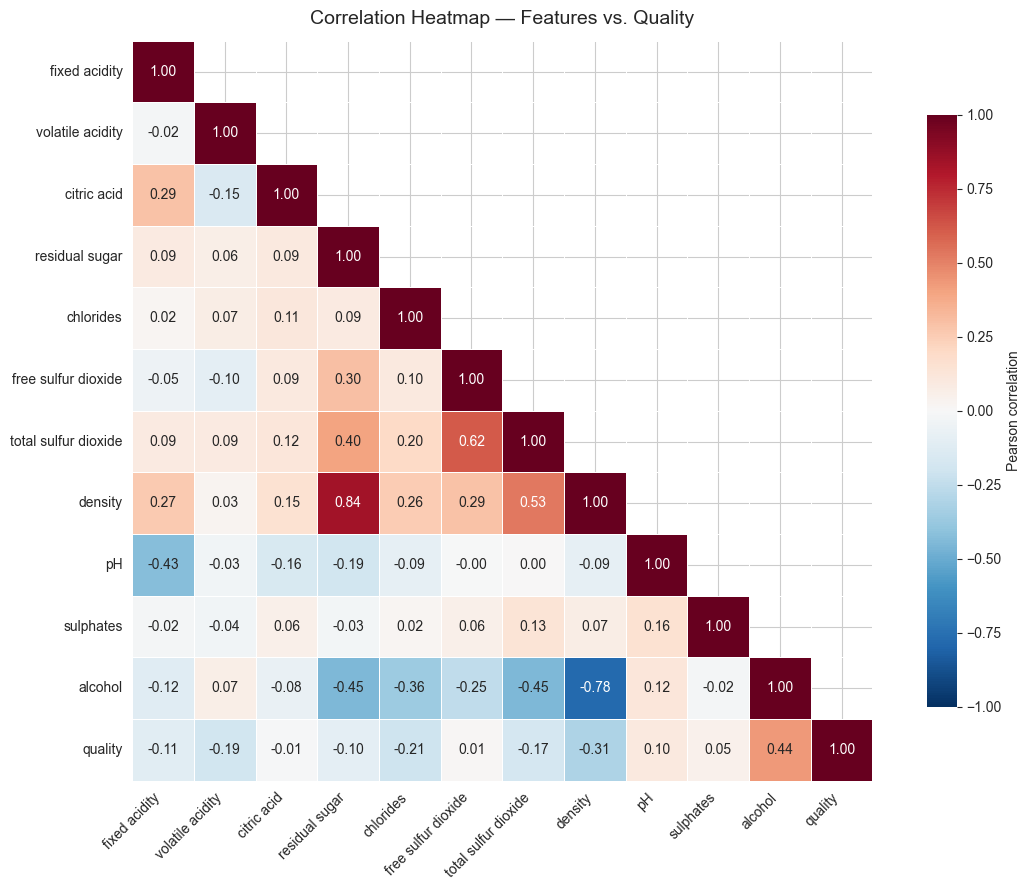

In [13]:
plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Pearson correlation"},
)
plt.title("Correlation Heatmap — Features vs. Quality", fontsize=14, pad=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

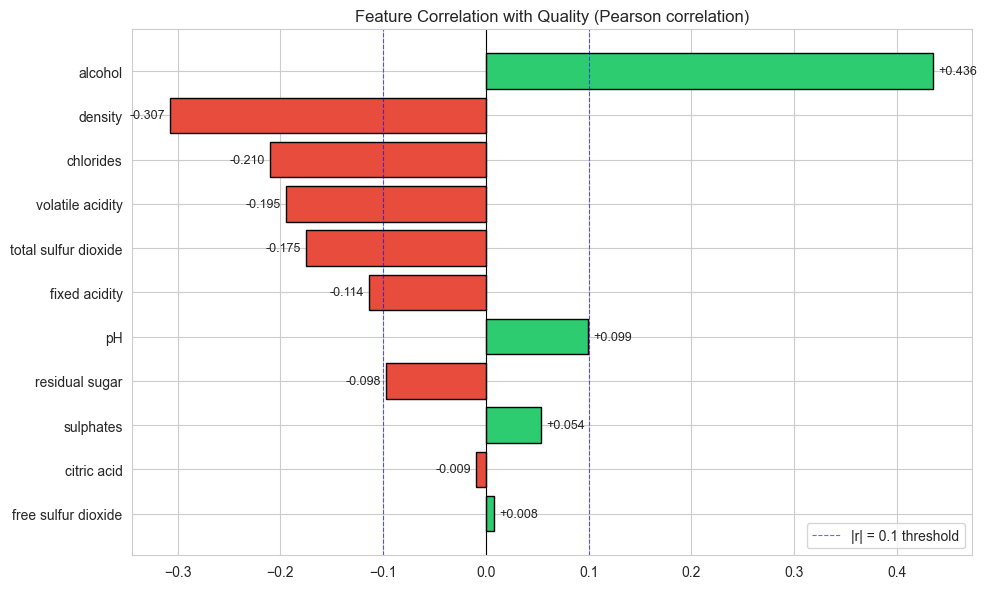

In [15]:
plt.figure(figsize=(10, 6))
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in target_corr.values]
bars = plt.barh(range(len(target_corr)), target_corr.values, color=colors, edgecolor="black")
plt.yticks(range(len(target_corr)), target_corr.index)
plt.axvline(0, color="black", linewidth=0.8)
plt.axvline(0.1, color="blue", linestyle="--", linewidth=0.8, alpha=0.6, label="|r| = 0.1 threshold")
plt.axvline(-0.1, color="blue", linestyle="--", linewidth=0.8, alpha=0.6)
plt.title("Feature Correlation with Quality (Pearson correlation)")
plt.gca().invert_yaxis()
for bar, v in zip(bars, target_corr.values):
    plt.text(v + (0.005 if v >= 0 else -0.005), bar.get_y() + bar.get_height() / 2,
             f"{v:+.3f}", va="center", ha="left" if v >= 0 else "right", fontsize=9)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [16]:
THRESHOLD = 0.10
BOUND = 0.6
selected = target_corr[target_corr.abs() >= THRESHOLD].index.tolist()
dropped_weak = [f for f in feature_cols if f not in selected]

print(f"Step 1 — keep |corr| >= {THRESHOLD}")
print(f"Kept    : {selected}")
print(f"Dropped : {dropped_weak}")

# Multicollinearity check
sel_corr = df[selected].corr().abs()
upper = sel_corr.where(np.triu(np.ones(sel_corr.shape), k=1).astype(bool))
high_pairs = [(c, r, upper.loc[r, c])
              for c in upper.columns for r in upper.index
              if pd.notnull(upper.loc[r, c]) and upper.loc[r, c] >= BOUND]

print(f"\nStep 2 — multicollinearity (|r| >= {BOUND} among selected):")
to_drop = set()
for a, b, v in high_pairs:
    print(f"  {a} <-> {b}: r = {v:.3f}")
    to_drop.add(a if abs(target_corr[a]) < abs(target_corr[b]) else b)

if to_drop:
    selected = [f for f in selected if f not in to_drop]
    print(f"  -> dropping: {sorted(to_drop)}")
else:
    print("  None found.")

print(f"\nFINAL SELECTED FEATURES ({len(selected)}): {selected}")

Step 1 — keep |corr| >= 0.1
Kept    : ['alcohol', 'density', 'chlorides', 'volatile acidity', 'total sulfur dioxide', 'fixed acidity']
Dropped : ['citric acid', 'residual sugar', 'free sulfur dioxide', 'pH', 'sulphates']

Step 2 — multicollinearity (|r| >= 0.6 among selected):
  density <-> alcohol: r = 0.780
  -> dropping: ['density']

FINAL SELECTED FEATURES (5): ['alcohol', 'chlorides', 'volatile acidity', 'total sulfur dioxide', 'fixed acidity']


In [17]:
X = df[selected].values
y = df[target_col].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [19]:
models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=500, max_depth=None, min_samples_split=2,
        random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "LightGBM": lgb.LGBMRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=-1, num_leaves=31,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
    ),
    "XGBoost": xgb.XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.9, colsample_bytree=0.9,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
    ),
    "CatBoost": CatBoostRegressor(
        iterations=500, learning_rate=0.05, depth=6,
        random_state=RANDOM_STATE, verbose=0,
    ),
}


results = []
preds_store = {}

for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    preds_store[name] = y_pred

    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)
    acc_rounded = np.mean(np.round(y_pred).clip(0, 10).astype(int) == y_test)

    results.append({
        "Model": name, "MAE": mae, "MSE": mse, "RMSE": rmse,
        "R2": r2, "ACC (rounded)": acc_rounded,
    })

    print(f"{name:<15} MAE={mae:.4f} | RMSE={rmse:.4f} | R2={r2:.4f} | Acc(rounded)={acc_rounded:.4f}")



Random Forest   MAE=0.4477 | RMSE=0.6301 | R2=0.4874 | Acc(rounded)=0.6735
LightGBM        MAE=0.5034 | RMSE=0.6724 | R2=0.4162 | Acc(rounded)=0.6173
XGBoost         MAE=0.4801 | RMSE=0.6534 | R2=0.4488 | Acc(rounded)=0.6510
CatBoost        MAE=0.5419 | RMSE=0.6905 | R2=0.3844 | Acc(rounded)=0.5602


In [20]:
results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
results_df.round(3)

,Model,MAE,MSE,RMSE,R2,ACC (rounded)
0,Random Forest,0.448,0.397,0.630,0.487,0.673
1,XGBoost,0.480,0.427,0.653,0.449,0.651
2,LightGBM,0.503,0.452,0.672,0.416,0.617
3,CatBoost,0.542,0.477,0.691,0.384,0.560


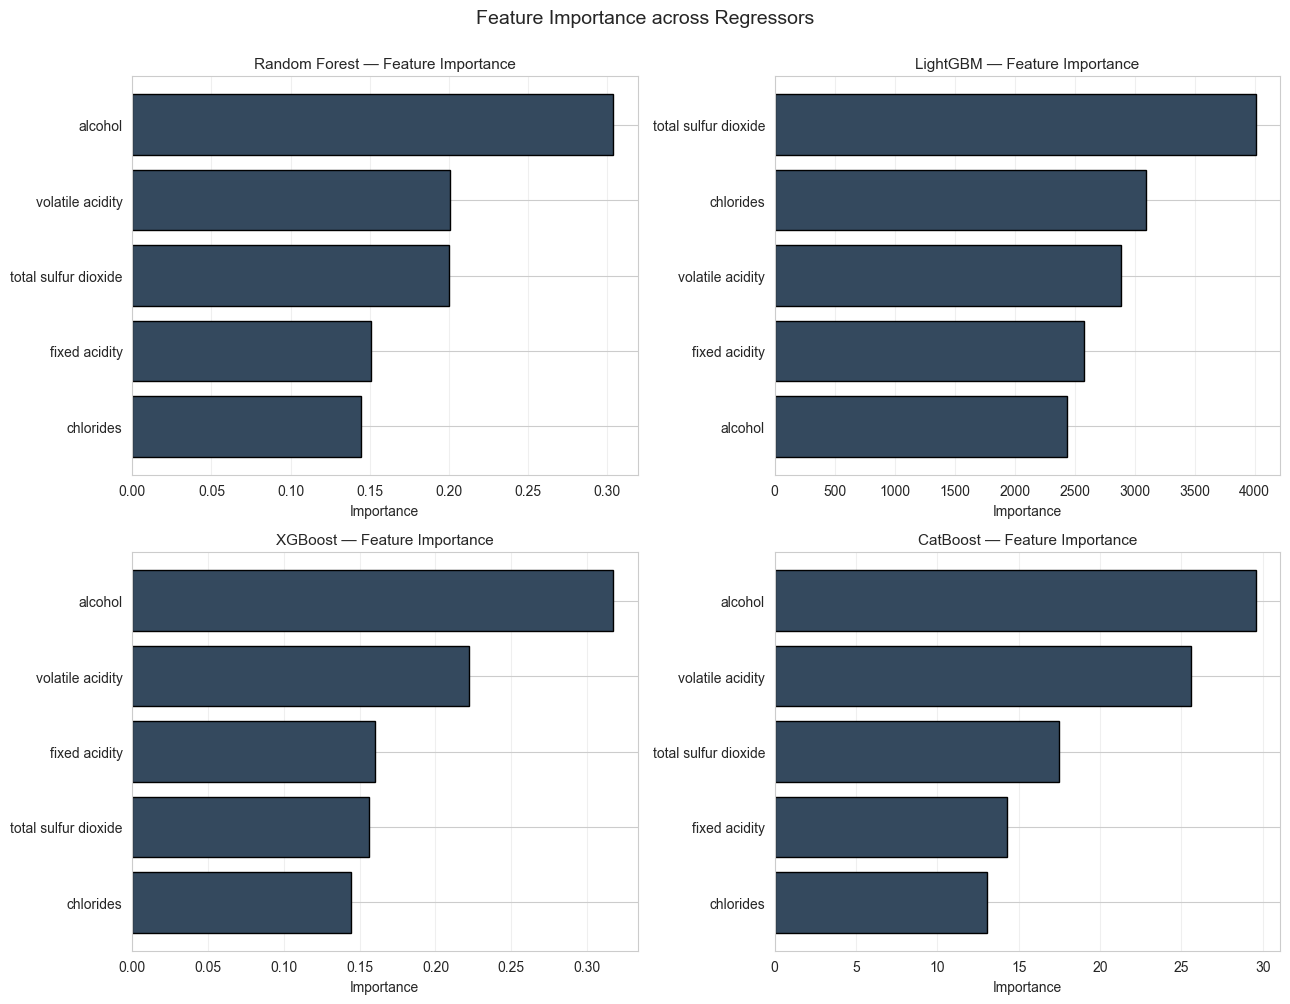

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, (name, model) in zip(axes.ravel(), models.items()):
    if hasattr(model, "feature_importances_"):
        imp = model.feature_importances_
    else:
        imp = model.get_feature_importance()
    imp_df = pd.DataFrame({"feature": selected, "importance": imp}) \
               .sort_values("importance", ascending=True)
    ax.barh(imp_df["feature"], imp_df["importance"], color="#34495e", edgecolor="black")
    ax.set_title(f"{name} — Feature Importance", fontsize=11)
    ax.set_xlabel("Importance")
    ax.grid(axis="x", alpha=0.3)
plt.suptitle("Feature Importance across Regressors", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

In [22]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    "n_estimators": [100, 200, 300, 500, 700, 1000], # More trees = more stable predictions but slower training
    "max_depth": [None, 5, 10, 15, 20, 30], # None = no limit. Shallower trees = simpler model, less overfitting
    "min_samples_split": [2, 5, 10, 15], # Minimum samples needed to split a node
    "min_samples_leaf": [1, 2, 4, 8], # Minimum samples in a leaf node. Higher = smoother predictions, less overfitting
    "max_features": ["sqrt", "log2", 0.5, 0.7, 1.0], # Number of features each tree considers per split
    "bootstrap": [True, False], # Sample training data with replacement or not
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=100,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

rf_search.fit(X_train_s, y_train)

print(f"\nBest RMSE (CV): {-rf_search.best_score_:.4f}")
print(f"Best params: {rf_search.best_params_}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits


/Users/lili/Documents/04.NhanHO/2026.Genesix/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/lili/Documents/04.NhanHO/2026.Genesix/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/lili/Documents/04.NhanHO/2026.Genesix/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warning


Best RMSE (CV): 0.6600
Best params: {'n_estimators': 1000, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'bootstrap': True}


In [23]:
# Evaluate the tuned model on the test set
rf_tuned = rf_search.best_estimator_
y_pred_tuned = rf_tuned.predict(X_test_s)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)
acc_tuned = np.mean(np.round(y_pred_tuned).clip(0, 10).astype(int) == y_test)

# Baseline (original RF)
y_pred_base = preds_store["Random Forest"]
mae_base = mean_absolute_error(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base = r2_score(y_test, y_pred_base)
acc_base = np.mean(np.round(y_pred_base).clip(0, 10).astype(int) == y_test)

comparison = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2", "Acc (rounded)"],
    "Baseline RF": [mae_base, rmse_base, r2_base, acc_base],
    "Tuned RF": [mae_tuned, rmse_tuned, r2_tuned, acc_tuned],
})

comparison["Improvement"] = comparison["Tuned RF"] - comparison["Baseline RF"]
comparison.round(3)

,Metric,Baseline RF,Tuned RF,Improvement
0,MAE,0.448,0.443,-0.005
1,RMSE,0.630,0.625,-0.005
2,R2,0.487,0.496,0.008
3,Acc (rounded),0.673,0.679,0.005
